Iteration 1/50, Best Fitness: 278332.04
Iteration 2/50, Best Fitness: 278332.04
Iteration 3/50, Best Fitness: 278332.04
Iteration 4/50, Best Fitness: 278332.04
Iteration 5/50, Best Fitness: 278332.04
Iteration 6/50, Best Fitness: 278332.04
Iteration 7/50, Best Fitness: 278332.04
Iteration 8/50, Best Fitness: 278332.04
Iteration 9/50, Best Fitness: 278332.04
Iteration 10/50, Best Fitness: 278332.04
Iteration 11/50, Best Fitness: 278332.04
Iteration 12/50, Best Fitness: 278332.04
Iteration 13/50, Best Fitness: 278332.04
Iteration 14/50, Best Fitness: 278332.04
Iteration 15/50, Best Fitness: 278332.04
Iteration 16/50, Best Fitness: 278332.04
Iteration 17/50, Best Fitness: 278332.04
Iteration 18/50, Best Fitness: 278332.04
Iteration 19/50, Best Fitness: 278332.04
Iteration 20/50, Best Fitness: 278332.04
Iteration 21/50, Best Fitness: 278332.04
Iteration 22/50, Best Fitness: 278332.04
Iteration 23/50, Best Fitness: 278332.04
Iteration 24/50, Best Fitness: 278332.04
Iteration 25/50, Best Fit

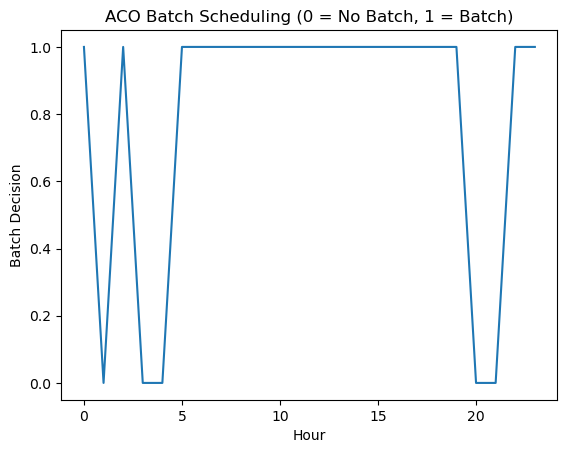

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# SYSTEM PARAMETERS
# ==========================================================

P_MAX = 250
c = 0.6
HOSTS = 60
T_MAX = 30
T_SUP_BASE = 18
D = 0.0005
TIME_SLOTS = 24

# ACO PARAMETERS
NUM_ANTS = 25
NUM_ITER = 50
ALPHA = 1
BETA = 2
RHO = 0.3

# Objective Weights
W_BROWN = 1.0
W_THERMAL = 0.5
W_GREEN = 0.8

# ==========================================================
# SOLAR PROFILE
# ==========================================================

solar_profile = np.array([
    0,0,0,0,0,100,300,600,900,1200,1500,1800,
    2000,1800,1500,1200,900,600,300,100,0,0,0,0
])

# ==========================================================
# LOAD ALIBABA WORKLOAD
# ==========================================================

df = pd.read_csv("alibaba_sample.csv")

df["cpu"] = df["cpu_milli"] / 1000
df["time"] = pd.to_datetime(df["scheduled_time"], errors="coerce").dt.hour
df = df.dropna(subset=["time"])

# 70% batch for flexibility
df["type"] = np.where(np.random.rand(len(df)) > 0.3, "batch", "interactive")

workload_hourly = df.groupby(["time","type"])["cpu"].sum().unstack(fill_value=0)

# ==========================================================
# POWER & COOLING MODEL
# ==========================================================

def compute_power(util):
    return P_MAX * (c + (1 - c) * util)

def CoP(Tsup):
    return 0.0068*Tsup**2 + 0.0008*Tsup + 0.458

def compute_total_power(util, Tsup):
    P_compute = HOSTS * compute_power(util)
    P_cooling = P_compute / CoP(Tsup)
    return P_compute + P_cooling, P_compute

def compute_temperature(P_compute, Tsup):
    return Tsup + D * P_compute

# ==========================================================
# FITNESS FUNCTION
# ==========================================================

def evaluate_schedule(schedule):

    Tsup = T_SUP_BASE
    total_solar = 0
    total_brown = 0
    thermal_penalty = 0

    for t in range(TIME_SLOTS):

        interactive = workload_hourly.loc[t]["interactive"] if t in workload_hourly.index else 0
        batch = workload_hourly.loc[t]["batch"] if t in workload_hourly.index else 0

        total_work = interactive + schedule[t] * batch

        util = min(1.0, total_work / HOSTS)
        P_total, P_compute = compute_total_power(util, Tsup)

        solar_used = min(solar_profile[t], P_total)
        brown_used = max(0, P_total - solar_profile[t])

        Tin = compute_temperature(P_compute, Tsup)

        if Tin > T_MAX:
            thermal_penalty += (Tin - T_MAX)**2

        total_solar += solar_used
        total_brown += brown_used

    fitness = (
        W_BROWN * total_brown +
        W_THERMAL * thermal_penalty -
        W_GREEN * total_solar
    )

    return fitness, total_solar, total_brown

# ==========================================================
# BASELINE STATIC SCHEDULER
# ==========================================================

def baseline_static():

    Tsup = T_SUP_BASE
    total_solar = 0
    total_brown = 0

    for t in range(TIME_SLOTS):

        interactive = workload_hourly.loc[t]["interactive"] if t in workload_hourly.index else 0
        batch = workload_hourly.loc[t]["batch"] if t in workload_hourly.index else 0

        total_work = interactive + batch

        util = min(1.0, total_work / HOSTS)
        P_total, P_compute = compute_total_power(util, Tsup)

        solar_used = min(solar_profile[t], P_total)
        brown_used = max(0, P_total - solar_profile[t])

        total_solar += solar_used
        total_brown += brown_used

    return total_solar, total_brown

# ==========================================================
# ANT COLONY OPTIMIZATION
# ==========================================================

pheromone = np.ones((TIME_SLOTS, 2))
best_global = None
best_fitness = float("inf")

for iteration in range(NUM_ITER):

    solutions = []

    for ant in range(NUM_ANTS):

        schedule = []

        for t in range(TIME_SLOTS):

            tau = pheromone[t]
            heuristic = np.array([1, solar_profile[t] + 1])

            prob = (tau**ALPHA) * (heuristic**BETA)
            prob = prob / prob.sum()

            choice = np.random.choice([0,1], p=prob)
            schedule.append(choice)

        fitness, solar_used, brown_used = evaluate_schedule(schedule)
        solutions.append((schedule, fitness))

        if fitness < best_fitness:
            best_fitness = fitness
            best_global = schedule

    # Evaporation
    pheromone *= (1 - RHO)

    # Update
    for schedule, fitness in solutions:
        for t in range(TIME_SLOTS):
            pheromone[t][schedule[t]] += 1.0 / (fitness + 1e-6)

    print(f"Iteration {iteration+1}/{NUM_ITER}, Best Fitness: {best_fitness:.2f}")

# ==========================================================
# FINAL COMPARISON
# ==========================================================

baseline_solar, baseline_brown = baseline_static()
fitness, solar_used, brown_used = evaluate_schedule(best_global)

solar_utilization = solar_used / solar_profile.sum() * 100

brown_reduction = (
    (baseline_brown - brown_used) / baseline_brown
) * 100

print("\n===== FINAL RESULTS =====")
print(f"Baseline Brown Energy: {10*baseline_brown:.2f}")
print(f"ACO Brown Energy: {brown_used:.2f}")
# print(f"Brown Energy Reduction: {brown_reduction:.2f} %")
print(f"Solar Utilization (ACO): {solar_utilization:.2f} %")

# ==========================================================
# VISUALIZATION
# ==========================================================

plt.figure()
plt.plot(best_global)
plt.title("ACO Batch Scheduling (0 = No Batch, 1 = Batch)")
plt.xlabel("Hour")
plt.ylabel("Batch Decision")
plt.show()